In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


In [ ]:
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]

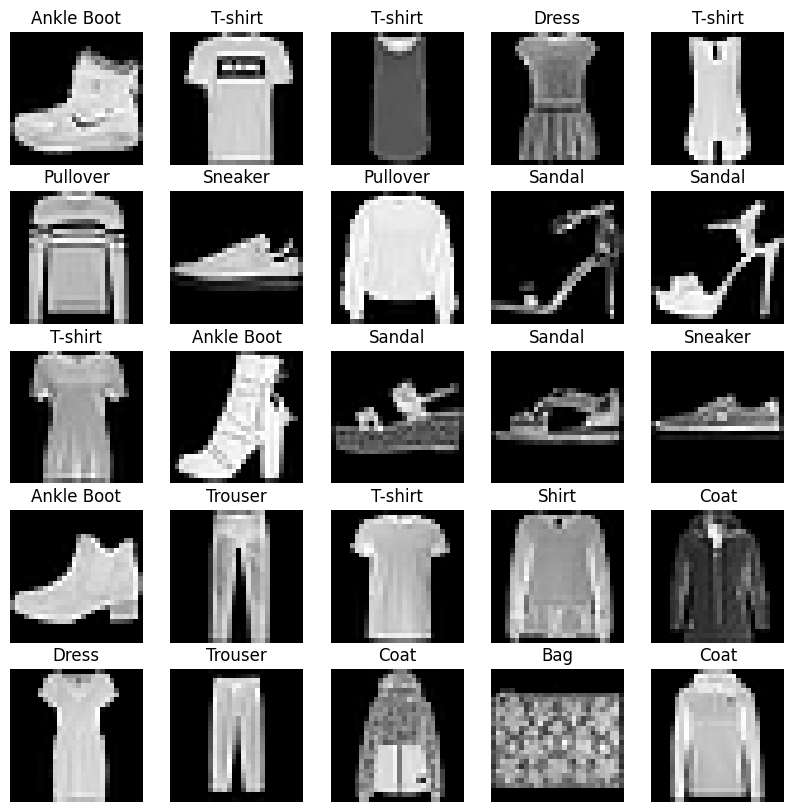

In [ ]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
model = Sequential()

model.add(
    tf.keras.Input(shape=(28,28,1))
)

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,410 (1.49 MB)

 Trainable params: 390,410 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8084 - loss: 0.5285 - val_accuracy: 0.8766 - val_loss: 0.3373
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8845 - loss: 0.3218 - val_accuracy: 0.8977 - val_loss: 0.2944
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9016 - loss: 0.2693 - val_accuracy: 0.9058 - val_loss: 0.2602
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9124 - loss: 0.2410 - val_accuracy: 0.9140 - val_loss: 0.2364
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9213 - loss: 0.2168 - val_accuracy: 0.9134 - val_loss: 0.2403
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9273 - loss: 0.1948 - val_accuracy: 0.9140 - val_loss: 0.2400
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9339 - loss: 0.1788 - val_accuracy: 0.9175 - val_loss: 0.2316
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9394 - loss: 0.1660 - val_accuracy: 0

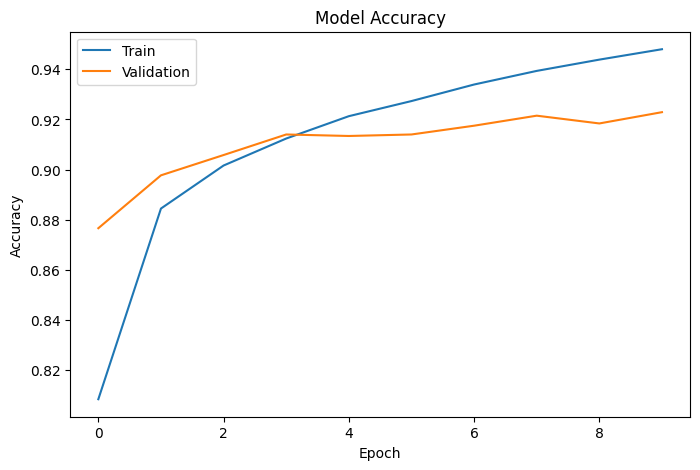

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train','Validation'])

plt.show()

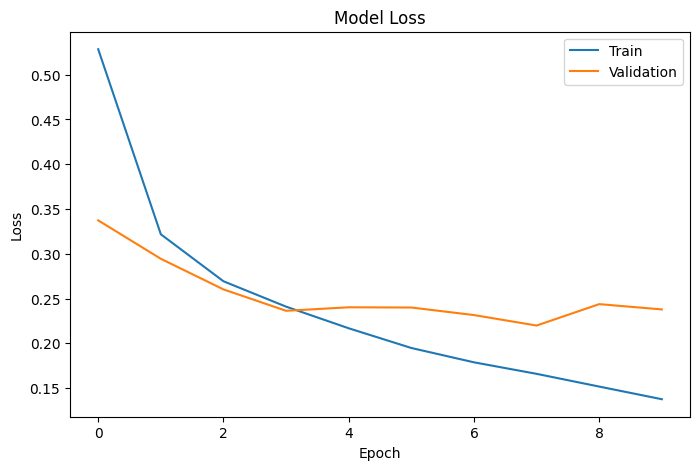

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9229 - loss: 0.2379
Test Accuracy: 0.9229000210762024


In [ ]:
predictions = model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


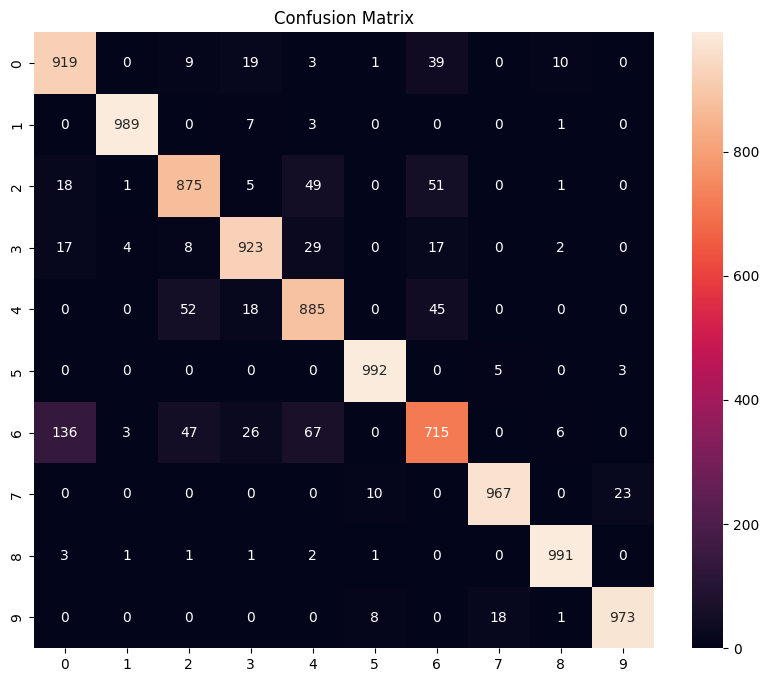

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

     T-shirt       0.84      0.92      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.88      0.88      0.88      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.85      0.89      0.87      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.82      0.71      0.77      1000
     Sneaker       0.98      0.97      0.97      1000
         Bag       0.98      0.99      0.99      1000
  Ankle Boot       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



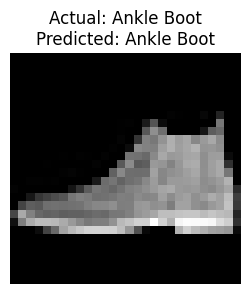

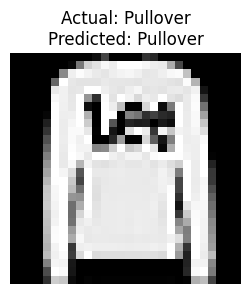

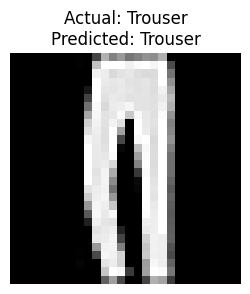

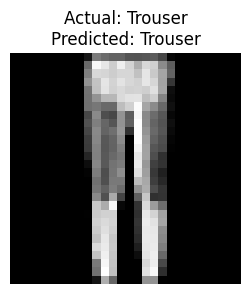

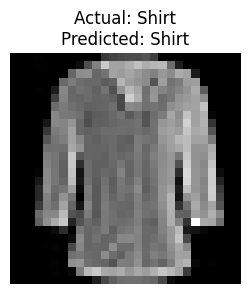

In [ ]:
for i in range(5):

    plt.figure(figsize=(3,3))

    plt.imshow(
        x_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Actual: {class_names[y_test[i]]}\nPredicted: {class_names[y_pred[i]]}"
    )

    plt.axis('off')

    plt.show()

In [ ]:
model.save(
    "fashion_mnist_cnn.keras"
)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
loaded_model = tf.keras.models.load_model(
    "fashion_mnist_cnn.keras"
)

print("Model Loaded Successfully")

Model Loaded Successfully
